In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import fock_dm, wigner

import h5py

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

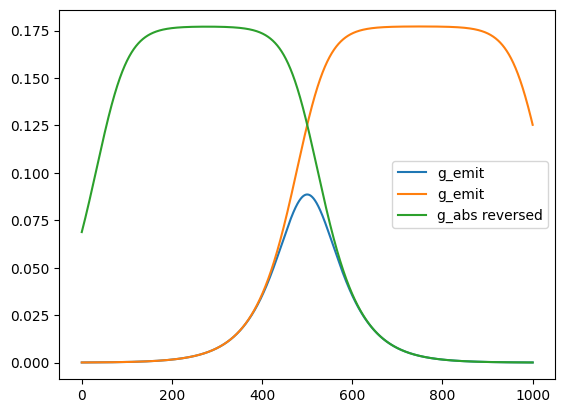

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

Delta_t = 1000
t = np.linspace(0, Delta_t, 4000)

xi_vals = xi_m(t-500, 0, kappa)

# cumulative integral
I_t = cumulative_trapezoid(np.abs(xi_vals)**2, t, initial=0)

# ===== 放出 =====
denom = 1 - I_t
denom[denom < 1e-12] = 1e-12
g_emit = np.conjugate(xi_vals) / np.sqrt(denom)

# ===== 吸収（時間反転）=====
denom = I_t
g_abs = np.conjugate(xi_vals) / np.sqrt(denom+0.000001)

plt.plot(t, np.real(xi_vals), label="g_emit")
plt.plot(t, np.real(g_emit), label="g_emit")
plt.plot(t, np.real(g_abs), label="g_abs reversed")
plt.legend()
plt.show()


In [4]:
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import hilbert
import matplotlib.gridspec as gridspec

def chronocyclic_wigner_padding(E_t, t, n_padding=10, plot_idx=0):
    N = len(t)
    dt = (t[1] - t[0])
    print(f"N = {N}, dt = {dt:.3e} s")

    N_pad = N * n_padding
    omega = np.fft.fftshift(np.fft.fftfreq(N_pad, dt)) * 2 * np.pi
    print(f"N_fft = {N_pad}, omega[0]={omega[0]:.3e}, omega[-1]={omega[-1]:.3e}, domega = {omega[1] - omega[0]:.3e}")

    W = np.zeros((N, N_pad), dtype=complex)
    tau_range = np.arange(-N//2, N//2) * dt
    dtau = tau_range[1] - tau_range[0]
    print(f"tau_range: {tau_range[0]:.3e} ... {tau_range[-1]:.3e}, dtau = {dtau:.3e}")

    print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))
    for i, ti in enumerate(t):
        Et_plus = np.interp(ti + tau_range/2, t, E_t, left=0, right=0)
        Et_minus = np.interp(ti - tau_range/2, t, np.conj(E_t), left=0, right=0)
        product = Et_plus * Et_minus

        pad_total = N_pad - N
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        product_padded = np.pad(product, (pad_left, pad_right), mode='constant')

        product_padded_shifted = np.fft.ifftshift(product_padded)
        W_fft = np.fft.fftshift(np.fft.fft(product_padded_shifted)) * dt / (2 * np.pi)
        W[i, :] = W_fft

        if plot_idx is not None and i == plot_idx:
            print(f"--- t[{i}] = {ti:.3e} ---")
            plt.figure(figsize=(6,4))
            plt.plot(t*1e9, np.real(Et_plus*Et_minus), label='Re(product)')
            plt.legend()
            plt.xlabel("Time [ns]")
            plt.show()

            plt.figure(figsize=(6,4))
            plt.plot(omega/(2*np.pi)*1e-9, np.real(W_fft), label='Re[W(t, ω)]')
            plt.plot(omega/(2*np.pi)*1e-9, np.imag(W_fft), label='Im[W(t, ω)]', linestyle='--')
            plt.plot(omega/(2*np.pi)*1e-9, np.abs(W_fft), label='|W(t, ω)|', linewidth=2, alpha=0.6)
            plt.xlabel("Frequency [GHz]")
            plt.ylabel("Amplitude")
            plt.title(f"Wigner FFT result at t = {ti*1e9:.1f} ns")
            plt.xlim(-0.02, 0.02)
            plt.legend()
            plt.grid()
            plt.show()

            print("FFT max:", np.max(np.abs(W_fft)))
            print("FFT sum:", np.sum(np.real(W_fft)) * (omega[1]-omega[0]))   

    total_energy = np.sum(np.real(W)) * (omega[1]-omega[0]) * dt
    print("=== Total integrated energy of Wigner function ===")
    print(total_energy)

    return np.real(W), omega

def energy_width(x, intensity, fraction=0.99):
    intensity = np.abs(intensity)**2
    intensity /= np.trapz(intensity, x)
    cumsum = np.cumsum(intensity)
    cumsum /= cumsum[-1]

    lower_idx = np.argmax(cumsum > (1 - fraction) / 2)
    upper_idx = np.argmax(cumsum >= 1 - (1 - fraction) / 2)
    width = x[upper_idx] - x[lower_idx]
    return width


In [5]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1040003526.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


=== Total integrated energy of Wigner function ===
1.0000000000003018


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1040003526.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization = np.trapz(np.trapz(W, omega, axis=1), t)
C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


Δt=296.00 ns, Δf=0.00700 GHz, TBP=2.07096

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000003018
Δt=388.00 ns, Δf=0.00900 GHz, TBP=3.49025

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000000003022
Δt=458.00 ns, Δf=0.01099 GHz, TBP=5.03548

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000000003022
Δt=516.00 ns, Δf=0.01199 GHz, TBP=6.18891



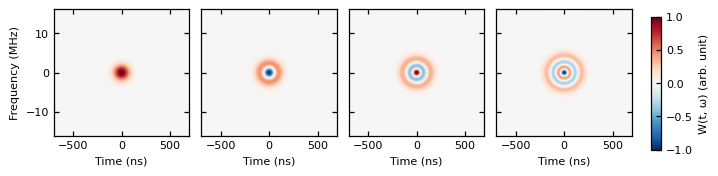

In [6]:
# Gaussian
from matplotlib.cm import ScalarMappable
def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return np.asarray(psi, dtype=np.float64) 

t_ns = np.linspace(-1000, 1000, 2001)
t = t_ns*1e-9
modes = [0, 1, 2, 3]
freq_max = 16e6
time_max = 700*1e-9
n_padding = 40
kappa_her = 12e-6*2*np.pi*2

results = []
for m in modes:
    E_t = hermite(t_ns, m, kappa_her)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapz(np.trapz(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 4, figsize=(6.8, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
         cmap=cmap, vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_xlabel("Time (ns)")
    if idx == 0:
        axes[idx].set_ylabel("Frequency (MHz)")
    # axes[idx].set_title(f"Mode {m}")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e1.pdf', dpi=300, bbox_inches='tight')
plt.show()


# fig3d = plt.figure(figsize=(8, 8))  # smaller overall size
# gs = gridspec.GridSpec(2, 2, figure=fig3d, wspace=0.2, hspace=0.3)
# axes3d = [fig3d.add_subplot(gs[i, j], projection="3d") for i in range(2) for j in range(2)]


# for idx, (ax, (m, time_crop, omega_crop, W_crop, _, _)) in enumerate(zip(axes3d, results)):
#     W_norm = W_crop / W_max_abs

#     T, Wm = np.meshgrid(time_crop*1e9, omega_crop*1e-9/(2*np.pi))
#     surf = ax.plot_surface(
#         T, Wm, W_norm.T,
#         cmap=cmap, linewidth=0, antialiased=True, vmin=-1, vmax=1
#     )
#     ax.set_xlabel("Time (ns)", labelpad=6)
#     ax.set_ylabel("Frequency (GHz)", labelpad=6)
#     ax.set_zlabel("W(t, ω)", labelpad=8)
#     ax.set_title(f"Mode m={m}", pad=10)
#     ax.view_init(elev=30, azim=-60)
#     ax.set_box_aspect((1, 1, 0.7))  # flatten z-axis a bit for compactness

# sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
# cbar_ax = fig3d.add_axes([1, 0.15, 0.02, 0.7])
# fig3d.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")

# plt.tight_layout(rect=[0, 0, 0.9, 0.95])
# plt.show()

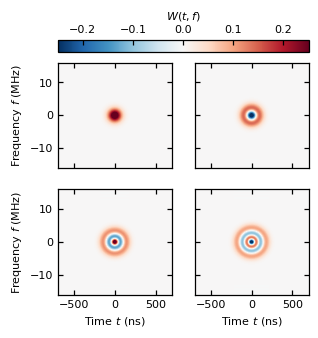

In [7]:

cmap = 'RdBu_r'
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(5, 7))
gs = GridSpec(4, 3, height_ratios=[1,1, 1,1], hspace=0.2)
axes_top = [[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)]

vmin=-0.25
vmax=0.25

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    row = idx // 2
    col = idx % 2
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)

    axes_top[row][col].pcolormesh(
        time_crop*1e9, omega_MHz, W_norm.T,
        cmap='RdBu_r', vmin=vmin, vmax=vmax, shading="auto",
        rasterized=True
    )
    axes_top[row][col].set_xticks([-500, 0, 500])
    axes_top[row][col].set_yticks([ -10,  0, 10])
    if idx in [0,2]:
        axes_top[row][col].set_ylabel(r"Frequency $f$ (MHz)")
    else:
        axes_top[row][col].tick_params(labelleft=False)
    if idx in [2,3]:
        axes_top[row][col].set_xlabel(r"Time $t$ (ns)")
    else:
        axes_top[row][col].tick_params(labelbottom=False)
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location='top',
    fraction=0.06, pad=0.04, orientation='horizontal'
)
cbar.set_label("$W(t, f)$")

for ax in fig.axes:
    for im in ax.get_images():
        im.set_rasterized(True)

plt.savefig('Figapp3_f1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from itertools import combinations_with_replacement

W_dict = {}
omega_dict = {}

for m in modes:
    E_t = xi_m(t_ns, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    W_dict[m] = W
    omega_dict[m] = omega

for m in modes:
    W = W_dict[m]
    omega = omega_dict[m]
    dt = t[1] - t[0]
    domega = np.abs(omega[1] - omega[0])

    norm = np.sum(W) * dt * domega
    W_dict[m] = W / norm

dt = t[1] - t[0]
domega = np.abs(omega[1] - omega[0])

# print("\n=== Mode overlaps from E_t inner products ===")
# for m1, m2 in combinations_with_replacement(modes, 2):
#     E1 = xi_m(t_ns, m1, kappa)
#     E1 /= np.sqrt(np.trapz(np.abs(E1)**2, t))
#     E2 = xi_m(t_ns, m2, kappa)
#     E2 /= np.sqrt(np.trapz(np.abs(E2)**2, t))
#     overlap_direct = np.trapz(np.conj(E1) * E2, t)
#     print(f"⟨E_{m1}|E_{m2}⟩ = {overlap_direct:.4f}   |⟨E_{m1}|E_{m2}⟩|² = {np.abs(overlap_direct)**2:.4f}")

print("\n=== Mode overlaps from Wigner functions ===")
for m1, m2 in combinations_with_replacement(modes, 2):
    W1 = W_dict[m1]
    W2 = W_dict[m2]
    overlap = 2 * np.pi * np.sum(W1 * W2) * dt * domega
    print(f"⟨W_{m1}|W_{m2}⟩ = {overlap:.4f}")


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\314589862.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000004


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


=== Total integrated energy of Wigner function ===
1.000000000000303
N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 0.9999999999999999
=== Total integrated energy of Wigner function ===
1.0000000000005158
N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000202354
N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.000000000843279

=== Mode overlaps from Wigner functions ===
⟨W_0|W_0⟩ = 1.0000
⟨W_0|W_1⟩ = 0.0000
⟨W_0|W_2⟩ = -0.0000
⟨W_0|W_3⟩ = 0.0000
⟨W_1|W_1⟩ = 1.0000
⟨W_1|W_2⟩ = 0.0000
⟨W_1|W_3⟩ = -0.0000
⟨W

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000004


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1203909.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


=== Total integrated energy of Wigner function ===
1.000000000000303


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1203909.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization = np.trapz(np.trapz(W, omega, axis=1), t)
C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 0.9999999999999999
=== Total integrated energy of Wigner function ===
1.0000000000005158
Δt=550.00 ns, Δf=0.01000 GHz, TBP=5.49725

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000202354
Δt=766.00 ns, Δf=0.01099 GHz, TBP=8.42179

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.000000000843279
Δt=978.00 ns, Δf=0.01099 GHz, TBP=10.75262



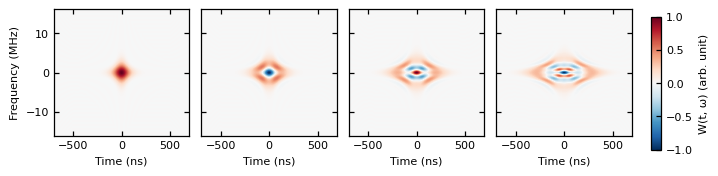

C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1203909.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


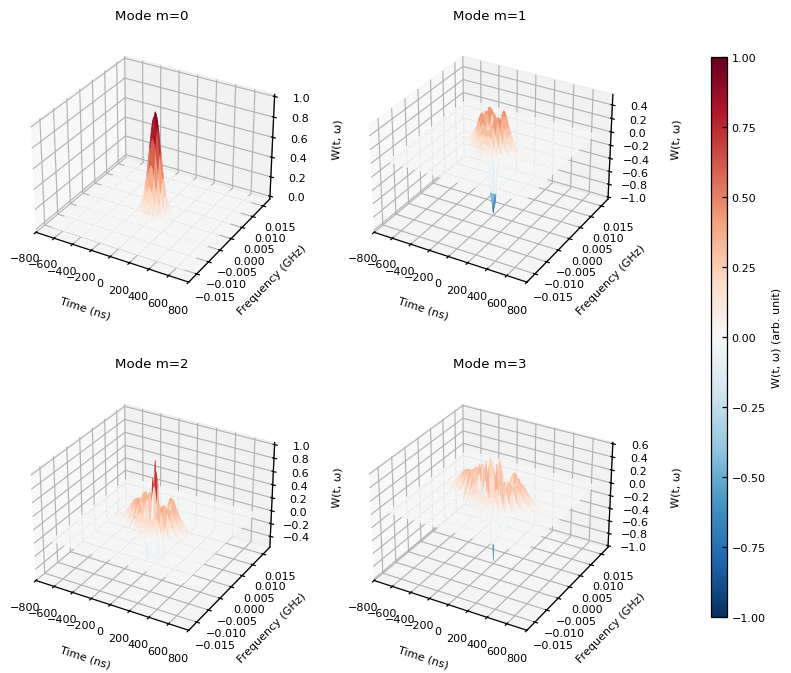

In [9]:


t_ns = np.linspace(-1000, 1000, 2001)
t = t_ns*1e-9
modes = [0, 1, 2, 3]
freq_max = 16e6
time_max = 700*1e-9
n_padding = 40

results = []
for m in modes:
    E_t = xi_m(t_ns, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapz(np.trapz(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 4, figsize=(6.8, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
         cmap=cmap, vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_xlabel("Time (ns)")
    if idx == 0:
        axes[idx].set_ylabel("Frequency (MHz)")
    # axes[idx].set_title(f"Mode {m}")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e1.pdf', dpi=300, bbox_inches='tight')
plt.show()



fig3d = plt.figure(figsize=(8, 8))  # smaller overall size
gs = gridspec.GridSpec(2, 2, figure=fig3d, wspace=0.2, hspace=0.3)
axes3d = [fig3d.add_subplot(gs[i, j], projection="3d") for i in range(2) for j in range(2)]


for idx, (ax, (m, time_crop, omega_crop, W_crop, _, _)) in enumerate(zip(axes3d, results)):
    W_norm = W_crop / W_max_abs

    T, Wm = np.meshgrid(time_crop*1e9, omega_crop*1e-9/(2*np.pi))
    surf = ax.plot_surface(
        T, Wm, W_norm.T,
        cmap=cmap, linewidth=0, antialiased=True, vmin=-1, vmax=1
    )
    ax.set_xlabel("Time (ns)", labelpad=6)
    ax.set_ylabel("Frequency (GHz)", labelpad=6)
    ax.set_zlabel("W(t, ω)", labelpad=8)
    ax.set_title(f"Mode m={m}", pad=10)
    ax.view_init(elev=30, azim=-60)
    ax.set_box_aspect((1, 1, 0.7))  # flatten z-axis a bit for compactness

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig3d.add_axes([1, 0.15, 0.02, 0.7])
fig3d.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

In [10]:


t_ns = np.linspace(-2000, 2000, 2001)
t = t_ns*1e-9
modes = [15]
freq_max = 40e6
time_max = 2000*1e-9
n_padding = 100

results = []
for m in modes:
    E_t = xi_m(t_ns, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapz(np.trapz(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1695826780.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 2.000e-09 s
N_fft = 200100, omega[0]=-1.571e+09, omega[-1]=1.571e+09, domega = 1.570e+04
tau_range: -2.002e-06 ... 1.998e-06, dtau = 2.000e-09
∫|E(t)|² dt = 1.0000000000000002


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


=== Total integrated energy of Wigner function ===
1.0000033602122806


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1695826780.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization = np.trapz(np.trapz(W, omega, axis=1), t)
C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


Δt=3448.00 ns, Δf=0.01399 GHz, TBP=48.24788



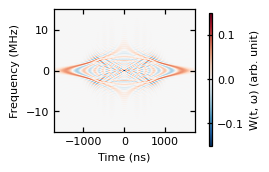

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(2.2, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    W_norm = W_crop# / W_max_abs
    im = axes.pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
         cmap=cmap, vmin=-0.15, vmax=0.15, rasterized=True
    )
    axes.set_xlabel("Time (ns)")
    if idx == 0:
        axes.set_ylabel("Frequency (MHz)")
    # axes[idx].set_title(f"Mode {m}")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.ylim(-15, 15)
plt.xlim(-3448/2, 3448/2)
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.15, vmax=0.15))
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e1.pdf', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1110284004.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 2.000e-09 s
N_fft = 200100, omega[0]=-1.571e+09, omega[-1]=1.571e+09, domega = 1.570e+04
tau_range: -2.002e-06 ... 1.998e-06, dtau = 2.000e-09
∫|E(t)|² dt = 0.9999999999999998


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


=== Total integrated energy of Wigner function ===
1.0000000000033387


C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\1110284004.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization = np.trapz(np.trapz(W, omega, axis=1), t)
C:\Users\qipe\AppData\Local\Temp\ipykernel_28764\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


Δt=336.00 ns, Δf=0.00850 GHz, TBP=2.85457



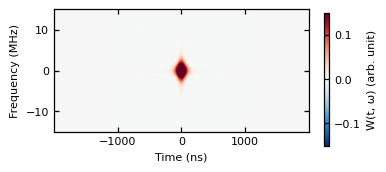

In [12]:
t_ns = np.linspace(-2000, 2000, 2001)
t = t_ns*1e-9
modes = [0]
freq_max = 40e6
time_max = 2000*1e-9
n_padding = 100

results1 = []
for m in modes:
    E_t = xi_m(t_ns, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapz(np.trapz(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results1.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 1, figsize=(3.4, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results1):
    W_norm = W_crop# / W_max_abs
    im = axes.pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
         cmap=cmap, vmin=-0.15, vmax=0.15, rasterized=True
    )
    axes.set_xlabel("Time (ns)")
    if idx == 0:
        axes.set_ylabel("Frequency (MHz)")
    # axes[idx].set_title(f"Mode {m}")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.ylim(-15, 15)
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.15, vmax=0.15))
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3.4, 1.9))
cmap = 'RdBu_r'

t_plot = time_crop * 1e9                 # ns
f_plot = omega_crop * 1e-6 / (2*np.pi)   # MHz

dt_grid = 336    # ns
df_grid = 8.5    # MHz

centers = [-1.5, -0.5, 0.5, 1.5]

for i in centers:
    for j in centers:
        t_shift = t_plot + i * dt_grid
        f_shift = f_plot + j * df_grid

        ax.pcolormesh(
            t_shift,
            f_shift,
            W_crop.T,
            cmap=cmap,
            vmin=-0.15,
            vmax=0.15,
            shading='auto'
        )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Frequency (MHz)")
ax.set_aspect('auto')

# 軸範囲をきれいに
ax.set_xlim(-2*dt_grid, 2*dt_grid)
ax.set_ylim(-2*df_grid, 2*df_grid)

# グリッド（格子感を出すならおすすめ）
ax.set_xticks(np.arange(-2, 3) * dt_grid)
ax.set_yticks(np.arange(-2, 3) * df_grid)
ax.grid(alpha=0.3)

# カラーバー
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-0.15, vmax=0.15))
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("W(t, ω) (arb. unit)")

plt.tight_layout()
plt.show()


MemoryError: Unable to allocate 61.0 MiB for an array with shape (32017, 1999) and data type bool

Error in callback <function _draw_all_if_interactive at 0x000001DC51E64AE0> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 1.91 GiB for an array with shape (32017, 1999, 4) and data type float64

MemoryError: Unable to allocate 1.91 GiB for an array with shape (32017, 1999, 4) and data type float64

<Figure size 340x190 with 1 Axes>

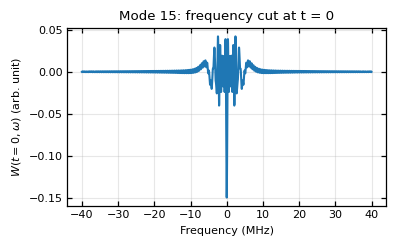

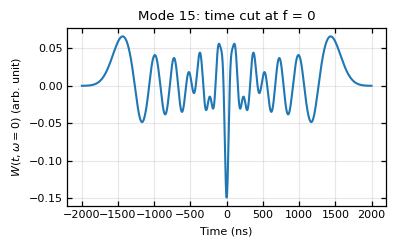

In [ ]:
# t=0 に最も近いインデックス
t0_idx = np.argmin(np.abs(time_crop))

# t=0 で切った周波数断面
W_t0 = W_norm[t0_idx, :]

plt.figure(figsize=(4, 2.5))
plt.plot(omega_crop*1e-6/(2*np.pi), W_t0, lw=1.5)
plt.xlabel("Frequency (MHz)")
plt.ylabel(r"$W(t=0,\omega)$ (arb. unit)")
plt.title("Mode 15: frequency cut at t = 0")
plt.grid(alpha=0.3)
# plt.ylim(-0.0125, 0.0125)
plt.tight_layout()
plt.show()

# ω=0 に最も近いインデックス
w0_idx = np.argmin(np.abs(omega_crop))

# ω=0 で切った時間断面
W_w0 = W_norm[:, w0_idx]

plt.figure(figsize=(4, 2.5))
plt.plot(time_crop*1e9, W_w0, lw=1.5)
plt.xlabel("Time (ns)")
plt.ylabel(r"$W(t,\omega=0)$ (arb. unit)")
plt.title("Mode 15: time cut at f = 0")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.ylim(-0.0125, 0.0125)
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_2340\2572257712.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_2340\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000004
=== Total integrated energy of Wigner function ===
1.0000000000003038


C:\Users\qipe\AppData\Local\Temp\ipykernel_2340\2572257712.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization = np.trapz(np.trapz(W, omega, axis=1), t)
C:\Users\qipe\AppData\Local\Temp\ipykernel_2340\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


Δt=1.68 ns, Δf=1.59920 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 0.9999999999999999
=== Total integrated energy of Wigner function ===
1.0000000000005147
Δt=2.75 ns, Δf=1.99900 GHz, TBP=5.49725

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000000202378
Δt=3.83 ns, Δf=2.19890 GHz, TBP=8.42179

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0
=== Total integrated energy of Wigner function ===
1.0000000008432823
Δt=4.89 ns, Δf=2.19890 GHz, TBP=10.75262



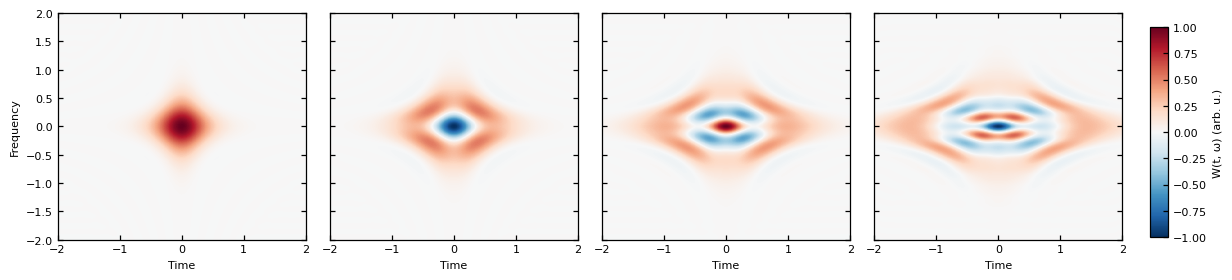

In [ ]:
# normalized

t_ns = np.linspace(-1000, 1000, 2001)
t = t_ns*1e-9
modes = [0, 1, 2, 3]
freq_max = 10e6
time_max = 300#*1e-9
n_padding = 40

results = []
for m in modes:
    E_t = xi_m(t_ns, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None)
    normalization = np.trapz(np.trapz(W, omega, axis=1), t)
    
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    gamma_ph = kappa / 2/np.pi 
    t_norm = time_crop * gamma_ph#/(2*np.pi)**2
    omega_norm = omega_crop / (gamma_ph)
    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9 * gamma_ph:.2f} ns, Δf={delta_f*1e-9/gamma_ph:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")

    results.append((m, t_norm, omega_norm, W_crop, delta_t, delta_f))


W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-9/2/np.pi, W_norm.T,
        shading='auto', cmap='RdBu_r', vmin=-1, vmax=1
    )
    axes[idx].set_xlabel("Time")
    if idx == 0:
        axes[idx].set_ylabel("Frequency")

    axes[idx].set_xlim([-2, 2])
    axes[idx].set_ylim([-2, 2])

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="W(t, ω) (arb. u.)")
plt.show()


## freq-bin encoding

C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\1839564393.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 0.9999999999999998
=== Total integrated energy of Wigner function ===
1.0000000000003058
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002


C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


=== Total integrated energy of Wigner function ===
1.0000000000003062
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000000003035
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 0.9999999999999998
=== Total integrated energy of Wigner function ===
1.0000000000003078
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666



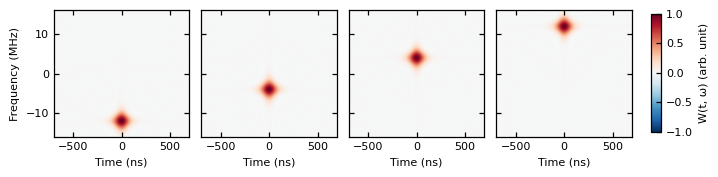

C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\1839564393.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


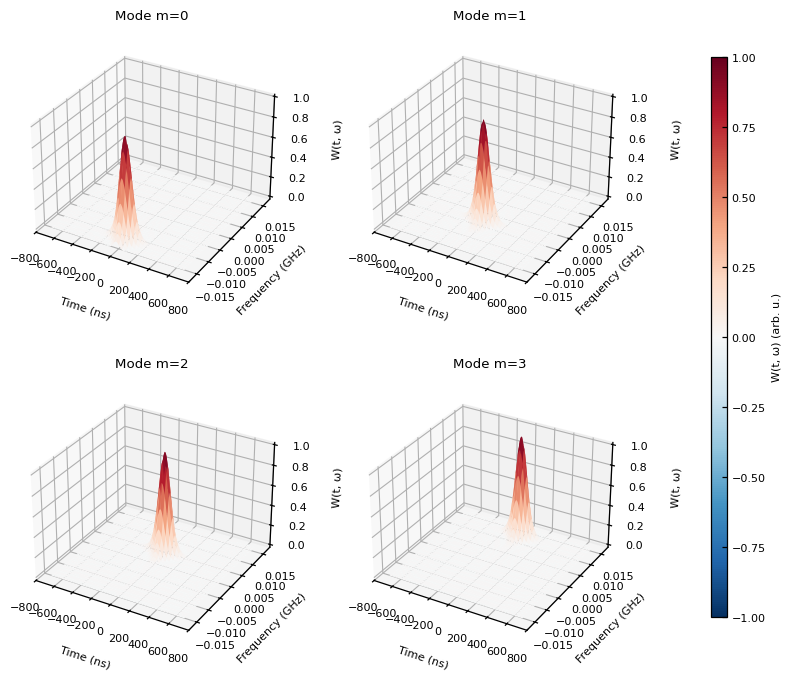

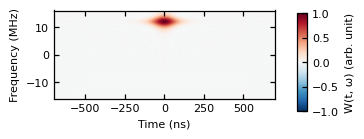

In [ ]:
delta_freq = 0.008
n_max = 4 
n_padding = 40
freq_max = 16e6
time_max = 700*1e-9
t_ns = np.linspace(-1000, 1000, 2001)
t = t_ns*1e-9
kappa = 2.5e-3*2*np.pi*2

def xi_m_freqbin(t, m, delta_freq, kappa, n_max): 
    t = np.asarray(t, dtype=np.float64) 
    base_waveform = np.asarray(xi_m(t, 0, kappa), dtype=np.complex128) 
    center = (n_max-1) / 2 
    freq_shift = float(delta_freq * (m - center)) 
    phase = np.exp(2j * np.pi * freq_shift * t) 
    return base_waveform * phase 

results_f = []
for idx, m in enumerate(modes): 
    E_t = xi_m_freqbin(t_ns, m, delta_freq, kappa, n_max) 
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t)) 
    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None) 
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")
    results_f.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results_f)

fig, axes = plt.subplots(1, 4, figsize=(6.8, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results_f):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
        cmap=cmap, vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_xlabel("Time (ns)")
    if idx == 0:
        axes[idx].set_ylabel("Frequency (MHz)")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.96, 0.25, 0.015, 0.62])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
# plt.savefig('Figapp3_e2.pdf', dpi=300, bbox_inches='tight')
plt.show()

# # === Plot cross sections of W(t, ω) ===
# for m, time_crop, omega_crop, W_crop, _, _ in results_f:
#     # t=0 cross section (frequency dependence)
#     idx_t0 = np.argmin(np.abs(time_crop))        # time ~ 0
#     W_t0 = np.abs(W_crop[idx_t0, :]) * 1e9       # same scaling as your color plots

#     # ω=0 cross section (time dependence)
#     idx_w0 = np.argmin(np.abs(omega_crop))       # omega ~ 0
#     W_w0 = np.abs(W_crop[:, idx_w0]) * 1e9

#     fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
#     # (a) t = 0
#     axes[0].plot(omega_crop/(2*np.pi*1e9), W_t0)
#     axes[0].set_xlabel("Frequency (GHz)")
#     axes[0].set_ylabel("|W(t=0, ω)| (arb. u.)")
#     axes[0].set_title(f"Mode m={m}: W(t=0, ω)")

#     # (b) ω = 0
#     axes[1].plot(time_crop*1e9, W_w0)
#     axes[1].set_xlabel("Time (ns)")
#     axes[1].set_ylabel("|W(t, ω=0)| (arb. u.)")
#     axes[1].set_title(f"Mode m={m}: W(t, ω=0)")

#     plt.tight_layout()
#     plt.show()

fig3d = plt.figure(figsize=(8, 8))  # smaller overall size
gs = gridspec.GridSpec(2, 2, figure=fig3d, wspace=0.2, hspace=0.3)
axes3d = [fig3d.add_subplot(gs[i, j], projection="3d") for i in range(2) for j in range(2)]

from matplotlib.cm import ScalarMappable
for idx, (ax, (m, time_crop, omega_crop, W_crop, _, _)) in enumerate(zip(axes3d, results_f)):
    W_norm = W_crop / W_max_abs

    T, Wm = np.meshgrid(time_crop*1e9, omega_crop*1e-9/(2*np.pi))
    surf = ax.plot_surface(
        T, Wm, W_norm.T,
        cmap="RdBu_r", linewidth=0, antialiased=True, vmin=-1, vmax=1
    )
    ax.set_xlabel("Time (ns)", labelpad=6)
    ax.set_ylabel("Frequency (GHz)", labelpad=6)
    ax.set_zlabel("W(t, ω)", labelpad=8)
    ax.set_title(f"Mode m={m}", pad=10)
    ax.view_init(elev=30, azim=-60)
    ax.set_box_aspect((1, 1, 0.7))  # flatten z-axis a bit for compactness

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig3d.add_axes([1, 0.15, 0.02, 0.7])
fig3d.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. u.)")
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

fig, ax = plt.subplots(figsize=(3.4, 1.5))

cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results_f):

    W_norm = W_crop / W_max_abs

    ax.pcolormesh(
        time_crop*1e9,
        omega_crop*1e-6/(2*np.pi),
        W_norm.T,
        cmap=cmap,
        vmin=-1, vmax=1,
        alpha=1,    
        rasterized=True
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Frequency (MHz)")

plt.tight_layout(rect=[0, 0, 0.85, 0.95])  

sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.88, 0.20, 0.03, 0.65])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")

# plt.savefig('Figapp3_e2_overlaid_small.pdf', dpi=300, bbox_inches='tight')
plt.show()


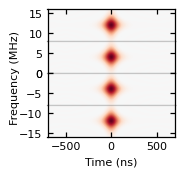

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(1.5, 1.5), sharex=True)  # sharex 追加
cmap = 'RdBu_r'

_, _, omega_crop0, _, _, _ = results_f[0]
omega_min = (omega_crop0*1e-6/(2*np.pi)).min()
omega_max = (omega_crop0*1e-6/(2*np.pi)).max()
domega = (omega_max - omega_min) / 4  # 1/4 区画幅
yticks_fixed = [-15, -10, -5, 0, 5, 10, 15]

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(reversed(results_f)):
    W_norm = W_crop / W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)

    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_MHz, W_norm.T,
        cmap=cmap, vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_yticks(yticks_fixed)

    y1 = omega_max - idx*domega
    y0 = omega_max - (idx+1)*domega
    axes[idx].set_ylim(y0, y1)

    if idx in [0,1,2]:
        axes[idx].tick_params(bottom=False, labelbottom=False)
        axes[idx].spines['bottom'].set_alpha(0.2)
    else:
        axes[idx].set_xlabel("Time (ns)")

    if idx in [1,2,3]:
        axes[idx].tick_params(top=False, labeltop=False)
        axes[idx].spines['top'].set_alpha(0.2)

fig.text(-0.15, 0.5, "Frequency (MHz)", va='center', rotation='vertical')

plt.subplots_adjust(hspace=0.0, left=0.1, right=0.95, top=0.95, bottom=0.1)
plt.show()


## Time-bin

C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\2716166656.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\3666436185.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("∫|E(t)|² dt =", np.trapz(np.abs(E_t)**2, t))


N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000026844935
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000004


C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


=== Total integrated energy of Wigner function ===
1.0000000000003713
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000000003622
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666

N = 2001, dt = 1.000e-09 s
N_fft = 80040, omega[0]=-3.142e+09, omega[-1]=3.142e+09, domega = 7.850e+04
tau_range: -1.001e-06 ... 9.990e-07, dtau = 1.000e-09
∫|E(t)|² dt = 1.0000000000000002
=== Total integrated energy of Wigner function ===
1.0000000026844882
Δt=336.00 ns, Δf=0.00800 GHz, TBP=2.68666



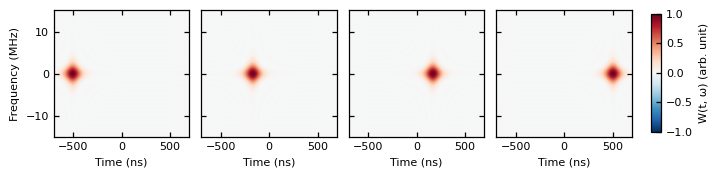

C:\Users\qipe\AppData\Local\Temp\ipykernel_27456\2716166656.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


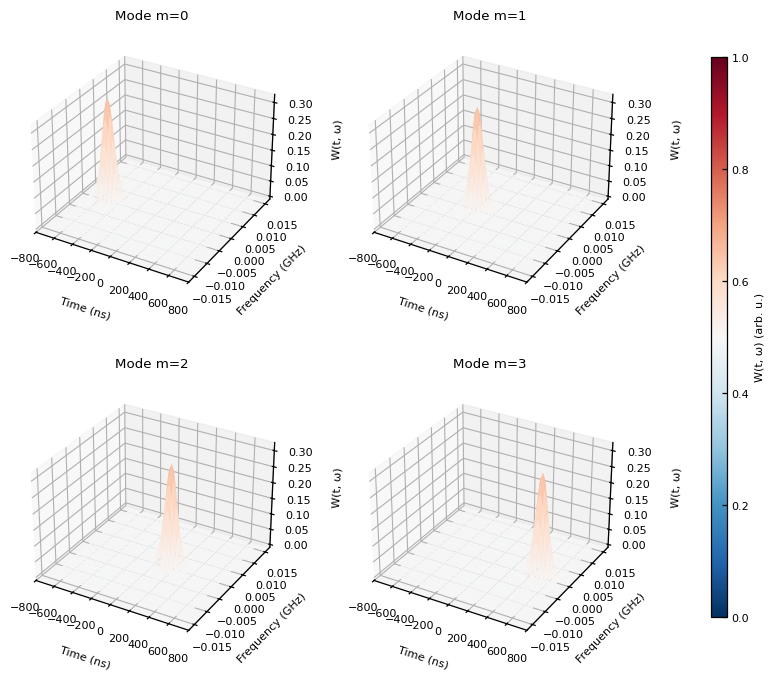

In [ ]:
duration = 336*4
n_max = 4 
n_padding = 40
freq_max = 15e6
time_max = 700*1e-9

def xi_m_shifted(t, m, m_tot, kappa):
    shift = duration * (2 * m + 1 - m_tot) / (2 * m_tot)
    return xi_m(t - shift, 0, kappa)

results_t = []
for idx, m in enumerate(modes): 
    E_t = xi_m_shifted(t_ns, m, 4, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t)) 
    W, omega = chronocyclic_wigner_padding(E_t, t, n_padding, None) 
    mask_f = np.abs(omega/(2*np.pi)) < freq_max
    omega_crop = omega[mask_f]
    W_crop_f = W[:, mask_f]
    mask_t = np.abs(t) < time_max
    time_crop = t[mask_t]
    W_crop = W_crop_f[mask_t, :]

    dt = t[1] - t[0]
    freq = fftshift(fftfreq(len(t), dt))
    E_f = fftshift(fft(E_t))
    delta_t = energy_width(t, E_t, fraction=0.99)
    delta_f = energy_width(freq, E_f, fraction=0.99)

    print(f"Δt={delta_t*1e9:.2f} ns, Δf={delta_f*1e-9:.5f} GHz, TBP={delta_t*delta_f:.5f}\n")
    results_t.append((m, time_crop, omega_crop, W_crop, delta_t, delta_f))

W_max_abs = max(np.max(np.abs(W_crop)) for _, _, _, W_crop, _, _ in results)

fig, axes = plt.subplots(1, 4, figsize=(6.8, 1.9), sharey=True)
cmap = 'RdBu_r'

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results_t):
    W_norm = W_crop / W_max_abs
    im = axes[idx].pcolormesh(
        time_crop*1e9, omega_crop*1e-6/(2*np.pi), W_norm.T,
        shading='auto', cmap='RdBu_r', vmin=-1, vmax=1, rasterized=True
    )
    axes[idx].set_xlabel("Time (ns)")
    if idx == 0:
        axes[idx].set_ylabel("Frequency (MHz)")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
sm = ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
cbar_ax = fig.add_axes([0.96, 0.25, 0.015, 0.62])
fig.colorbar(sm, cax=cbar_ax, label="W(t, ω) (arb. unit)")
plt.savefig('Figapp3_e3.pdf', dpi=300, bbox_inches='tight')
plt.show()

# === Plot cross sections of W(t, ω) ===
# for m, time_crop, omega_crop, W_crop, _, _ in results_t:
#     # t=0 cross section (frequency dependence)
#     idx_t0 = np.argmin(np.abs(time_crop))        # time ~ 0
#     W_t0 = np.abs(W_crop[idx_t0, :]) * 1e9       # same scaling as your color plots

#     # ω=0 cross section (time dependence)
#     idx_w0 = np.argmin(np.abs(omega_crop))       # omega ~ 0
#     W_w0 = np.abs(W_crop[:, idx_w0]) * 1e9

#     fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
#     # (a) t = 0
#     axes[0].plot(omega_crop/(2*np.pi*1e9), W_t0)
#     axes[0].set_xlabel("Frequency (GHz)")
#     axes[0].set_ylabel("|W(t=0, ω)| (arb. u.)")
#     axes[0].set_title(f"Mode m={m}: W(t=0, ω)")

#     # (b) ω = 0
#     axes[1].plot(time_crop*1e9, W_w0)
#     axes[1].set_xlabel("Time (ns)")
#     axes[1].set_ylabel("|W(t, ω=0)| (arb. u.)")
#     axes[1].set_title(f"Mode m={m}: W(t, ω=0)")

#     plt.tight_layout()
#     plt.show()

fig3d = plt.figure(figsize=(8, 8))  # smaller overall size
gs = gridspec.GridSpec(2, 2, figure=fig3d, wspace=0.2, hspace=0.3)
axes3d = [fig3d.add_subplot(gs[i, j], projection="3d") for i in range(2) for j in range(2)]

from matplotlib.cm import ScalarMappable

for idx, (ax, (m, time_crop, omega_crop, W_crop, _, _)) in enumerate(zip(axes3d, results_t)):
    W_norm = W_crop #/ W_max_abs
    T, Wm = np.meshgrid(time_crop*1e9, omega_crop*1e-9/(2*np.pi))
    surf = ax.plot_surface(
        T, Wm, W_norm.T,
        cmap="RdBu_r", linewidth=0, antialiased=True, vmin=-1, vmax=1
    )
    ax.set_xlabel("Time (ns)", labelpad=6)
    ax.set_ylabel("Frequency (GHz)", labelpad=6)
    ax.set_zlabel("W(t, ω)", labelpad=8)
    ax.set_title(f"Mode m={m}", pad=10)
    ax.view_init(elev=30, azim=-60)
    ax.set_box_aspect((1, 1, 0.7))  # flatten z-axis a bit for compactness

cbar_ax = fig3d.add_axes([1, 0.15, 0.02, 0.7])
fig3d.colorbar(ScalarMappable(cmap="RdBu_r"), cax=cbar_ax, label="W(t, ω) (arb. u.)")

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

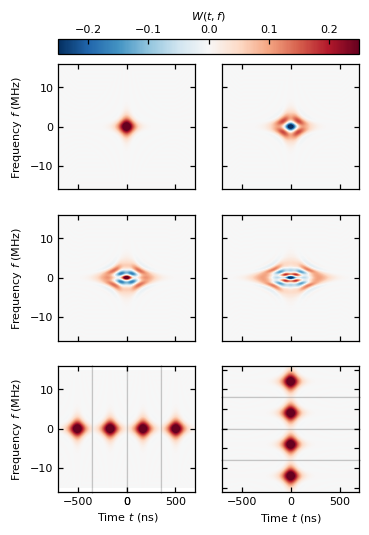

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.ticker as ticker

cmap = 'RdBu_r'
fig = plt.figure(figsize=(6, 8))
gs = GridSpec(4, 3, height_ratios=[1,1, 1,1], hspace=0.2)
axes_top = [[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)]

vmin=-0.25
vmax=0.25
for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    row = idx // 2
    col = idx % 2
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)

    axes_top[row][col].pcolormesh(
        time_crop*1e9, omega_MHz, W_norm.T,
        cmap='RdBu_r', vmin=vmin, vmax=vmax, shading="auto",
        rasterized=True
    )
    axes_top[row][col].set_xticks([-500, 0, 500])
    axes_top[row][col].tick_params(labelbottom=False)
    axes_top[row][col].set_yticks([-10,0,10])
    if idx in [0,2]:
        axes_top[row][col].set_ylabel(r"Frequency $f$ (MHz)")
    else:
        axes_top[row][col].tick_params(labelleft=False)

# ==================
# 左下: results_f の4枚をまとめる
# ==================
ax_left = fig.add_subplot(gs[2, 1])
ax_left.axis("off") 
axes_left = [ax_left.inset_axes([0, 0.75-i*0.25, 1, 0.25]) for i in range(4)]  # 縦4分割
_, _, omega_crop0, _, _, _ = results_f[0]
omega_min = (omega_crop0*1e-6/(2*np.pi)).min()
omega_max = (omega_crop0*1e-6/(2*np.pi)).max()
domega = (omega_max - omega_min) / 4 
time_min = -time_max

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(reversed(results_f)):
    W_norm = W_crop #/ W_max_abs
    axes_left[idx].pcolormesh(time_crop*1e9, omega_MHz, W_norm.T, cmap=cmap, vmin=vmin, vmax=vmax,
    rasterized=True)
    y1 = omega_max - idx*domega
    y0 = omega_max - (idx+1)*domega
    axes_left[idx].set_ylim(y0, y1)
    axes_left[idx].set_xlim(time_min*1e9, time_max*1e9)
    axes_left[idx].tick_params(labelleft=False)
    if idx < 3:
        axes_left[idx].tick_params(bottom=False, labelbottom=False)
        axes_left[idx].spines['bottom'].set_alpha(0.2)
    else:
        axes_left[idx].set_xlabel(r"Time $t$ (ns)")
    if idx > 0:
        axes_left[idx].tick_params(top=False, labeltop=False)
        axes_left[idx].spines['top'].set_alpha(0.2)

# ==================
# 右下: results_t の4枚をまとめる
# ==================
ax_right = fig.add_subplot(gs[2, 0])
axes_right = [ax_right.inset_axes([i*0.25, 0, 0.25, 1]) for i in range(4)]  # 縦に4分割
ax_right.axis("off") 

dtime = time_max*2/4
for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results_t):
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)
    axes_right[idx].pcolormesh(time_crop*1e9, omega_MHz, W_norm.T, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto",
    rasterized=True)
    axes_right[idx].set_xticks([-500, 0, 500])
    x1 = time_min + (idx+1)*dtime
    x0 = time_min + idx*dtime
    axes_right[idx].set_xlim(x0*1e9, x1*1e9)
    axes_right[idx].set_ylim(omega_min, omega_max) 
    axes_right[idx].set_yticks([-10,0,10])
    if idx in [0,1,2]:
        axes_right[idx].tick_params(right=False, labelright=False)
        # axes_right[idx].tick_params(labelleft=False)
        axes_right[idx].spines['right'].set_alpha(0.2)
    else:
        axes_right[idx].set_xlabel(r"Time $t$ (ns)")
        axes_right[idx].xaxis.set_label_coords(-0.95, -0.15) 
    if idx in [1,2,3]:
        axes_right[idx].tick_params(left=False, labelleft=False)
        axes_right[idx].spines['left'].set_alpha(0.2)
    if idx == 1:
        axes_right[idx].set_ylabel(r"Frequency $f$ (MHz)")
        axes_right[idx].yaxis.set_label_coords(-2, 0.5) 
    
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location='top',
    fraction=0.04, pad=0.02, orientation='horizontal'
)
cbar.set_label("$W(t, f)$")

cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])           # 0.5 間隔で ticks
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # 小数点1桁
cbar.update_ticks()

for ax in fig.axes:
    for im in ax.get_images():
        im.set_rasterized(True)


# plt.savefig('Fig4_d1.pdf', dpi=300, bbox_inches='tight')
plt.show()

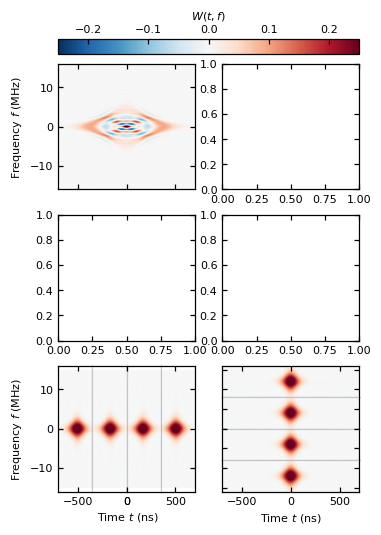

In [106]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.ticker as ticker

cmap = 'RdBu_r'
fig = plt.figure(figsize=(6, 8))
gs = GridSpec(4, 3, height_ratios=[1,1, 1,1], hspace=0.2)
axes_top = [[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)]

vmin=-0.25
vmax=0.25
for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results):
    row = idx // 2
    col = idx % 2
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)

    axes_top[row][col].pcolormesh(
        time_crop*1e9, omega_MHz, W_norm.T,
        cmap='RdBu_r', vmin=vmin, vmax=vmax, shading="auto",
        rasterized=True
    )
    axes_top[row][col].set_xticks([-500, 0, 500])
    axes_top[row][col].tick_params(labelbottom=False)
    axes_top[row][col].set_yticks([-10,0,10])
    if idx in [0,2]:
        axes_top[row][col].set_ylabel(r"Frequency $f$ (MHz)")
    else:
        axes_top[row][col].tick_params(labelleft=False)

# ==================
# 左下: results_f の4枚をまとめる
# ==================
ax_left = fig.add_subplot(gs[2, 1])
ax_left.axis("off") 
axes_left = [ax_left.inset_axes([0, 0.75-i*0.25, 1, 0.25]) for i in range(4)]  # 縦4分割
_, _, omega_crop0, _, _, _ = results_f[0]
omega_min = (omega_crop0*1e-6/(2*np.pi)).min()
omega_max = (omega_crop0*1e-6/(2*np.pi)).max()
domega = (omega_max - omega_min) / 4 
time_min = -time_max

for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(reversed(results_f)):
    W_norm = W_crop #/ W_max_abs
    axes_left[idx].pcolormesh(time_crop*1e9, omega_MHz, W_norm.T, cmap=cmap, vmin=vmin, vmax=vmax,
    rasterized=True)
    y1 = omega_max - idx*domega
    y0 = omega_max - (idx+1)*domega
    axes_left[idx].set_ylim(y0, y1)
    axes_left[idx].set_xlim(time_min*1e9, time_max*1e9)
    axes_left[idx].tick_params(labelleft=False)
    if idx < 3:
        axes_left[idx].tick_params(bottom=False, labelbottom=False)
        axes_left[idx].spines['bottom'].set_alpha(0.2)
    else:
        axes_left[idx].set_xlabel(r"Time $t$ (ns)")
    if idx > 0:
        axes_left[idx].tick_params(top=False, labeltop=False)
        axes_left[idx].spines['top'].set_alpha(0.2)

# ==================
# 右下: results_t の4枚をまとめる
# ==================
ax_right = fig.add_subplot(gs[2, 0])
axes_right = [ax_right.inset_axes([i*0.25, 0, 0.25, 1]) for i in range(4)]  # 縦に4分割
ax_right.axis("off") 

dtime = time_max*2/4
for idx, (m, time_crop, omega_crop, W_crop, _, _) in enumerate(results_t):
    W_norm = W_crop #/ W_max_abs
    omega_MHz = omega_crop*1e-6/(2*np.pi)
    axes_right[idx].pcolormesh(time_crop*1e9, omega_MHz, W_norm.T, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto",
    rasterized=True)
    axes_right[idx].set_xticks([-500, 0, 500])
    x1 = time_min + (idx+1)*dtime
    x0 = time_min + idx*dtime
    axes_right[idx].set_xlim(x0*1e9, x1*1e9)
    axes_right[idx].set_ylim(omega_min, omega_max) 
    axes_right[idx].set_yticks([-10,0,10])
    if idx in [0,1,2]:
        axes_right[idx].tick_params(right=False, labelright=False)
        # axes_right[idx].tick_params(labelleft=False)
        axes_right[idx].spines['right'].set_alpha(0.2)
    else:
        axes_right[idx].set_xlabel(r"Time $t$ (ns)")
        axes_right[idx].xaxis.set_label_coords(-0.95, -0.15) 
    if idx in [1,2,3]:
        axes_right[idx].tick_params(left=False, labelleft=False)
        axes_right[idx].spines['left'].set_alpha(0.2)
    if idx == 1:
        axes_right[idx].set_ylabel(r"Frequency $f$ (MHz)")
        axes_right[idx].yaxis.set_label_coords(-2, 0.5) 
    
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location='top',
    fraction=0.04, pad=0.02, orientation='horizontal'
)
cbar.set_label("$W(t, f)$")

cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])           # 0.5 間隔で ticks
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # 小数点1桁
cbar.update_ticks()

for ax in fig.axes:
    for im in ax.get_images():
        im.set_rasterized(True)


# plt.savefig('Fig4_d1.pdf', dpi=300, bbox_inches='tight')
plt.show()

the number of modes

In [27]:
kappa = 2.5e-3*2*np.pi*2
# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator     
                  / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

C:\Users\qipe\AppData\Local\Temp\ipykernel_23596\2311101792.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_23596\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


[-1.25       -1.24999938 -1.24999875 ...  1.24999813  1.24999875
  1.24999938]
Mode 21: Δt = 4669.60, Δf = 0.01433
Mode 22: Δt = 4872.00, Δf = 0.01440
Mode 23: Δt = 5074.40, Δf = 0.01446
Mode 24: Δt = 5276.80, Δf = 0.01452
Mode 25: Δt = 5479.20, Δf = 0.01458
Mode 26: Δt = 5681.60, Δf = 0.01464
Mode 27: Δt = 5883.20, Δf = 0.01470
Mode 28: Δt = 6084.80, Δf = 0.01476
Mode 29: Δt = 6304.00, Δf = 0.01418
Mode 30: Δt = 6510.40, Δf = 0.01385
Mode 31: Δt = 6218.40, Δf = 0.01403
Mode 32: Δt = 6454.40, Δf = 0.01350
Mode 33: Δt = 6148.00, Δf = 0.01408
Mode 34: Δt = 6400.80, Δf = 0.01347
Time-bin: 5 modes
Freq-bin: 3 modes
Temporal-mode: 8 modes


C:\Users\qipe\AppData\Local\Temp\ipykernel_23596\2311101792.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


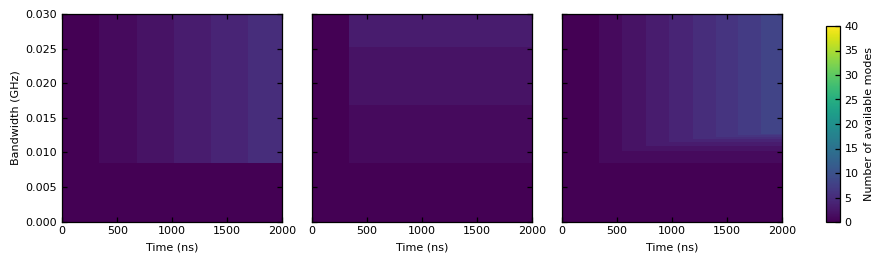

In [29]:
# Temporal-mode
modes_list = list(range(35))
temporal_mode_params = {}
t = np.linspace(-8000, 8000, 40001)

for m in modes_list:
    E_t = xi_m(t, m, kappa)
    E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

    dt = t[1] - t[0]
    N = len(t)
    N_pad = N * n_padding

    # --- time domain (no padding needed for Δt) ---
    delta_t = energy_width(t, E_t, fraction=0.99)

    pad_total = N_pad - N
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    E_t_padded = np.pad(E_t, (pad_left, pad_right), mode="constant")

    freq = np.fft.fftshift(np.fft.fftfreq(N_pad, dt))  # frequency grid
    E_f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(E_t_padded)))

    delta_f = energy_width(freq, E_f, fraction=0.99)


    temporal_mode_params[m] = {"delta_t": delta_t, "delta_f": delta_f}

print(freq)

# params 辞書に追加
params = {
    "Time-bin": {"delta_t": temporal_mode_params[0]["delta_t"],
                    "delta_f": temporal_mode_params[0]["delta_f"]},   # Δt in ns, Δf in MHz
    "Freq-bin": {"delta_t": temporal_mode_params[0]["delta_t"],
                    "delta_f": temporal_mode_params[0]["delta_f"]},
    "Temporal-mode": temporal_mode_params
}

# 確認
for m, p in temporal_mode_params.items():
    if m > 20:
        print(f"Mode {m}: Δt = {p['delta_t']:.2f}, Δf = {p['delta_f']:.5f}")

T_max = 2000   # ns
F_max = 0.03  # MHz
T_vals = np.linspace(0, T_max, 500)
F_vals = np.linspace(0, F_max, 500)
TT, FF = np.meshgrid(T_vals, F_vals)

def n_time_bin(T, delta_t, F, min_F):
    n = np.floor(T / delta_t).astype(int)
    n = np.where(F >= min_F, n, 0)
    return n

def n_freq_bin(F, delta_f, T, min_T):
    n = np.floor(F / delta_f).astype(int)
    n = np.where(T >= min_T, n, 0)
    return n

def n_temporal_modes(T, F, temporal_mode_params):
    n_modes_map = np.zeros_like(T, dtype=int)
    for m, p in temporal_mode_params.items():
        mask = (T >= p["delta_t"]) & (F >= p["delta_f"])
        n_modes_map[mask] += 1
    return n_modes_map


maps = {
    "Time-bin": n_time_bin(TT, params["Time-bin"]["delta_t"],
                           FF, params["Time-bin"]["delta_f"]),
    "Freq-bin": n_freq_bin(FF, params["Freq-bin"]["delta_f"],
                           TT, params["Freq-bin"]["delta_t"]),
    "Temporal-mode": n_temporal_modes(TT, FF,
                                     params["Temporal-mode"])
}

fig, axes = plt.subplots(1, 3, figsize=(9, 2.8), sharey=True)
plt.subplots_adjust(wspace=0.1)

vmax = 40#max(m.max() for m in maps.values())

for ax, (label, data) in zip(axes, maps.items()):
    im = ax.pcolormesh(TT, FF, data, shading='auto', cmap='viridis', vmin=0, vmax=vmax)
    print(rf"{label}: {data.max()} modes")
    # ax.set_title(label, fontsize=12)
    ax.set_xlabel("Time (ns)")
    ax.set_xlim(0, T_max)
    ax.set_ylim(0, F_max)
    if label == "Time-bin":
        ax.set_ylabel("Bandwidth (GHz)")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Number of available modes")

# fig.suptitle("Comparison of mode number in (time, frequency) space", fontsize=15, y=1.03)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_23596\244494506.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
C:\Users\qipe\AppData\Local\Temp\ipykernel_23596\3666436185.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intensity /= np.trapz(intensity, x)


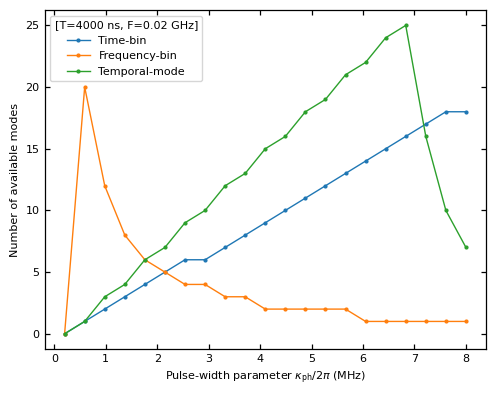

In [32]:
def compute_max_modes(kappa, t, modes_list, T_max, F_max):
    temporal_mode_params = {}
    for m in modes_list:
        E_t = xi_m(t, m, kappa)
        E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
        dt = t[1] - t[0]
        N = len(t)
        N_pad = N * n_padding
        # --- time domain (no padding needed for Δt) ---
        delta_t = energy_width(t, E_t, fraction=0.99)

        # --- frequency domain (padding to refine resolution) ---
        # zero-padding in time domain before FFT
        pad_total = N_pad - N
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        E_t_padded = np.pad(E_t, (pad_left, pad_right), mode="constant")

        freq = np.fft.fftshift(np.fft.fftfreq(N_pad, dt))  # frequency grid
        E_f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(E_t_padded)))

        delta_f = energy_width(freq, E_f, fraction=0.99)
        temporal_mode_params[m] = {"delta_t": delta_t, "delta_f": delta_f}
        # print("delta_t", delta_t, "delta_f", delta_f)

    params = {
        "Time-bin": {"delta_t": temporal_mode_params[0]["delta_t"],
                     "delta_f": temporal_mode_params[0]["delta_f"]},
        "Frequency-bin": {"delta_t": temporal_mode_params[0]["delta_t"],
                     "delta_f": temporal_mode_params[0]["delta_f"]},
        "Temporal-mode": temporal_mode_params
    }

    T_vals = np.linspace(0, T_max, 400)
    F_vals = np.linspace(0, F_max, 400)
    TT, FF = np.meshgrid(T_vals, F_vals)

    def n_time_bin(T, delta_t, F, min_F):
        n = np.floor(T / delta_t).astype(int)
        n = np.where(F >= min_F, n, 0)
        return n

    def n_freq_bin(F, delta_f, T, min_T):
        n = np.floor(F / delta_f).astype(int)
        n = np.where(T >= min_T, n, 0)
        # print(T, min_T)
        return n

    def n_temporal_modes(T, F, temporal_mode_params):
        n_modes_map = np.zeros_like(T, dtype=int)
        for m, p in temporal_mode_params.items():
            mask = (T >= p["delta_t"]) & (F >= p["delta_f"])
            n_modes_map[mask] += 1
        return n_modes_map

    maps = {
        "Time-bin": n_time_bin(TT, params["Time-bin"]["delta_t"],
                               FF, params["Time-bin"]["delta_f"]),
        "Frequency-bin": n_freq_bin(FF, params["Frequency-bin"]["delta_f"],
                               TT, params["Frequency-bin"]["delta_t"]),
        "Temporal-mode": n_temporal_modes(TT, FF,
                                          params["Temporal-mode"])
    }

    max_modes = {label: data.max() for label, data in maps.items()}
    # print(max_modes)
    return max_modes

kappa_list = np.linspace(0.1, 4., 21)*1e-3*2*np.pi*2 
modes_list = list(range(30))
t = np.linspace(-8000, 8000, 10001)
T_max = 4000
F_max1 = 0.02

results_014 = {"Time-bin": [], "Frequency-bin": [], "Temporal-mode": []}

for k in kappa_list:
    max_modes = compute_max_modes(k, t, modes_list, T_max, F_max1)
    for key in results_014.keys():
        results_014[key].append(max_modes[key])

plt.figure(figsize=(5, 4))
lines = {}
for key, vals in results_014.items():
    line, = plt.plot(kappa_list/(1e-3*2*np.pi), vals, marker='o', label=key)#+f" (F={F_max1} GHz)")
    lines[key] = line 


plt.xlabel(r"Pulse-width parameter $\kappa_{\mathrm{ph}}/2\pi$ (MHz)")
plt.ylabel("Number of available modes")
plt.legend(title=f"[T={T_max} ns, F={F_max1} GHz]")
plt.tight_layout()
plt.show()

In [582]:
def find_kappa_min_for_T(T_max, t, modes_list):
    """
    Find the smallest kappa such that delta_t(kappa) < T_max.
    """
    kappa_candidates = np.linspace(0.1, 4.0, 50) * 1e-3 * 2 * np.pi * 2  # sweep fine
    delta_t_list = []

    for k in kappa_candidates:
        E_t = xi_m(t, 0, k)
        E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))
        delta_t = energy_width(t, E_t, fraction=0.99)
        delta_t_list.append(delta_t)

    delta_t_list = np.array(delta_t_list)

    mask = delta_t_list < T_max
    if np.any(mask):
        return kappa_candidates[np.where(mask)[0][0]]  # 最初に満たすkappa
    else:
        return kappa_candidates[-1] 

def find_kappa_max_for_F(F_max, t, modes_list, n_padding=40):
    """
    Find the largest kappa such that delta_f(kappa) < F_max.
    """
    kappa_candidates = np.linspace(0.1, 4.0, 50) * 1e-3 * 2 * np.pi * 2  # fine sweep
    delta_f_list = []

    for k in kappa_candidates:
        E_t = xi_m(t, 0, k)
        E_t /= np.sqrt(np.trapz(np.abs(E_t)**2, t))

        dt = t[1] - t[0]
        N = len(t)
        N_pad = N * n_padding

        # zero-padding for frequency resolution
        pad_total = N_pad - N
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        E_t_padded = np.pad(E_t, (pad_left, pad_right), mode="constant")

        freq = np.fft.fftshift(np.fft.fftfreq(N_pad, dt))
        E_f = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(E_t_padded)))

        delta_f = energy_width(freq, E_f, fraction=0.99)
        delta_f_list.append(delta_f)

    delta_f_list = np.array(delta_f_list)

    # kappa が小さいほど周波数幅が狭くなるので、delta_f < F_max を満たす最後の kappa を返す
    mask = delta_f_list < F_max
    if np.any(mask):
        return kappa_candidates[np.where(mask)[0][-1]]  # 最後に満たす kappa
    else:
        return kappa_candidates[0]  # どれも満たさない場合は最小値


In [ ]:
from tqdm import tqdm
modes_list = list(range(30))
t = np.linspace(-4000, 4000, 10001)

T_vals = np.linspace(200, 4000, 21)   # [ns]
F_vals = np.linspace(0.005, 0.06, 21)   # [GHz]

maps_3d = {
    "Time-bin": np.zeros((len(F_vals), len(T_vals))),
    "Frequency-bin": np.zeros((len(F_vals), len(T_vals))),
    "Temporal-mode": np.zeros((len(F_vals), len(T_vals))),
}

kappa_values = np.linspace(0.1, 4.0, 40) * 1e-3 * 2 * np.pi * 2

for iF, F_max in enumerate(tqdm(F_vals, desc="Sweeping F")):
    for iT, T_max in enumerate(tqdm(T_vals, desc="Sweeping T", leave=False)):
        for key in ["Time-bin", "Frequency-bin", "Temporal-mode"]:

            if key == "Frequency-bin":
                kappa_iter = kappa_values
            else:
                kappa_iter = kappa_values[::-1]

            best_val = -np.inf
            decreasing = False

            for k in kappa_iter:
                max_modes = compute_max_modes(k, t, modes_list, T_max, F_max)
                val = max_modes[key]

                if val < best_val:
                    decreasing = True
                    break

                best_val = val

            maps_3d[key][iF, iT] = best_val

T_grid, F_grid = np.meshgrid(T_vals, F_vals)

vmin = min(np.min(maps_3d[key]) for key in maps_3d)
vmax = max(np.max(maps_3d[key]) for key in maps_3d)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5), sharey=True)

for ax, key in zip(axes, maps_3d.keys()):
    im = ax.pcolormesh(
        T_grid, F_grid, maps_3d[key],
        shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
    )
    ax.set_title(key)
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Bandwidth (GHz)")

plt.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Number of available modes")

plt.show()


# with h5py.File("maps_3d_results_1110.h5", "w") as f:
#     for key, data in maps_3d.items():
#         f.create_dataset(key, data=data)

# maps_3d_loaded_10 = {}
# with h5py.File("maps_3d_results_1110.h5", "r") as f:
#     for key in f.keys():
#         maps_3d_loaded_10[key] = f[key][:]

In [6]:
maps_3d_loaded_10 = {}
with h5py.File("maps_3d_results_1110.h5", "r") as f:
    for key in f.keys():
        maps_3d_loaded_10[key] = f[key][:]

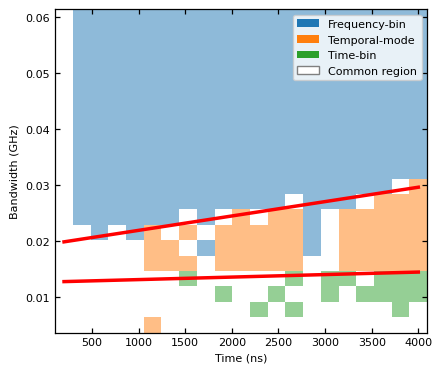

In [7]:
from scipy.ndimage import generic_filter
from matplotlib.patches import Patch

T_vals = np.linspace(200, 4000, 21)   # [ns]
F_vals = np.linspace(0.005, 0.06, 21)   # [GHz]

T_grid, F_grid = np.meshgrid(T_vals, F_vals)
encoding_keys = list(maps_3d_loaded_10.keys())
maps_stack = np.stack([maps_3d_loaded_10[key] for key in encoding_keys], axis=0)

max_idx = np.argmax(maps_stack, axis=0)
max_values = np.max(maps_stack, axis=0)
max_counts = (maps_stack == max_values).sum(axis=0)

mask_unique = (max_values > 0) & (max_counts == 1)
max_idx_masked = np.full_like(max_idx, np.nan, dtype=float)
max_idx_masked[mask_unique] = max_idx[mask_unique]

def is_boundary(arr):
    center = arr[4]
    if center == -1:
        return False
    neighbors = np.delete(arr, 4)
    return np.any(neighbors != center)

max_idx_filled = np.nan_to_num(max_idx_masked, nan=-1)
boundary_mask = generic_filter(max_idx_filled, function=is_boundary, size=3, mode='constant', cval=-1)

boundary_T = T_grid[boundary_mask.astype(bool)]
boundary_F = F_grid[boundary_mask.astype(bool)]
boundary_enc = max_idx_filled[boundary_mask.astype(bool)]

idx_freq = encoding_keys.index("Frequency-bin")
idx_temp = encoding_keys.index("Temporal-mode")
idx_time = encoding_keys.index("Time-bin")

# ===============================================================
#  Frequency-bin and Temporal-mode boundary
# ===============================================================
mid_T_1, mid_F_1 = [], []

for T_val in np.unique(boundary_T):
    mask_T = np.isclose(boundary_T, T_val)
    F_points = boundary_F[mask_T]
    enc_points = boundary_enc[mask_T]

    mask_freq = enc_points == idx_freq
    mask_temp = enc_points == idx_temp

    if np.any(mask_freq) and np.any(mask_temp):
        F_min = np.min(F_points[mask_freq]) 
        F_max = np.max(F_points[mask_temp]) 
        mid_T_1.append(T_val)
        mid_F_1.append((F_min + F_max) / 2)

mid_T_1 = np.array(mid_T_1)
mid_F_1 = np.array(mid_F_1)

if len(mid_T_1) > 1:
    p1 = np.polyfit(mid_T_1, mid_F_1, 1)
    T_line_1 = np.array([T_vals.min(), T_vals.max()])
    F_line_1 = p1[0] * T_line_1 + p1[1]
else:
    p1 = None

# ===============================================================
# 2️Temporal-mode and Time-bin boundary
# ===============================================================
mid_T_2, mid_F_2 = [], []

for T_val in np.unique(boundary_T):
    mask_T = np.isclose(boundary_T, T_val)
    F_points = boundary_F[mask_T]
    enc_points = boundary_enc[mask_T]

    mask_temp = enc_points == idx_temp
    mask_time = enc_points == idx_time

    if np.any(mask_temp) and np.any(mask_time):
        F_min = np.min(F_points[mask_temp]) 
        F_max = np.max(F_points[mask_time]) 
        mid_T_2.append(T_val)
        mid_F_2.append((F_min + F_max) / 2)

mid_T_2 = np.array(mid_T_2)
mid_F_2 = np.array(mid_F_2)

if len(mid_T_2) > 1:
    p2 = np.polyfit(mid_T_2, mid_F_2, 1)
    T_line_2 = np.array([T_vals.min(), T_vals.max()])
    F_line_2 = p2[0] * T_line_2 + p2[1]
else:
    p2 = None

# ===============================================================
# figure
# ===============================================================
color_map_dict = { 
    "Temporal-mode": "#ff7f0e",  
    "Time-bin": "#2ca02c",  
    "Frequency-bin": "#1f77b4",   
}

fig, ax = plt.subplots(figsize=(4.8,4.2))
colors = [color_map_dict[k] for k in encoding_keys]
cmap = plt.matplotlib.colors.ListedColormap(colors)


# 背景：dominant encoding map
im = ax.pcolormesh(T_grid, F_grid, max_idx_masked, shading="auto",
                   cmap=cmap, vmin=0, vmax=len(encoding_keys)-1, alpha=0.5)

if p1 is not None:
    ax.plot(T_line_1, F_line_1, 'r-', lw=2.5, label='Freq-bin ↔ Temp-mode')
if p2 is not None:
    ax.plot(T_line_2, F_line_2, 'r-', lw=2.5, label='Temp-mode ↔ Time-bin')

# 凡例
legend_elements = [Patch(facecolor=cmap(i), label=encoding_keys[i]) for i in range(len(encoding_keys))]
legend_elements.append(Patch(facecolor='white', edgecolor='gray', label='Common region'))
ax.legend(handles=legend_elements,
          loc='upper right')

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Bandwidth (GHz)")
# ax.set_title("Boundaries between encoding regions")

plt.show()


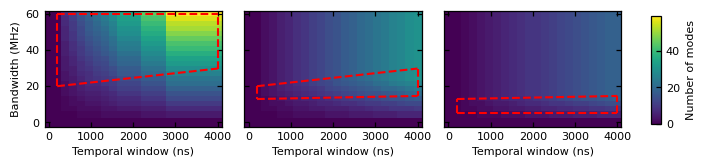

In [8]:
T_grid, F_grid = np.meshgrid(T_vals, F_vals)

encoding_keys = list(maps_3d_loaded_10.keys())

# 各マップの周囲に0行・0列を追加
maps_padded = {}
for key in encoding_keys:
    M = maps_3d_loaded_10[key]
    # 下端に0行、左端に0列を追加
    M_padded = np.pad(M, ((1, 0), (1, 0)), mode='constant', constant_values=0)
    maps_padded[key] = M_padded

# 軸に対応する値も同様に拡張
T_vals_padded = np.insert(T_vals, 0, 0)
F_vals_padded = np.insert(F_vals, 0, 0)
T_grid, F_grid = np.meshgrid(T_vals_padded, F_vals_padded)

maps_stack = np.stack([maps_padded[key] for key in encoding_keys], axis=0)
max_values = maps_stack.max(axis=0) 
max_counts = (maps_stack == max_values).sum(axis=0)

vmin = maps_stack.min()
vmax = maps_stack.max()

fig, axes = plt.subplots(1, 3, figsize=(6.8, 1.8), sharey=True)

for ax, key, color in zip(axes, encoding_keys, colors):
    im = ax.pcolormesh(
        T_grid, F_grid*1e3, maps_padded[key],
        shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
    )

    
    ax.set_xlabel("Temporal window (ns)")
    if key=="Frequency-bin":
        ax.set_ylabel("Bandwidth (MHz)")
        ax.plot([T_vals.min(), T_vals.min()], [F_line_1.min()*1e3, F_vals.max()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.min(), T_vals.max()], [F_vals.max()*1e3, F_vals.max()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_line_1.max()*1e3, F_vals.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_1, F_line_1*1e3, 'r--', lw=1.5)
    elif key=="Temporal-mode":
        ax.plot([T_vals.min(), T_vals.min()], [F_line_1.min()*1e3, F_line_2.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_line_1.max()*1e3, F_line_2.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_1, F_line_1*1e3, 'r--', lw=1.5)
        ax.plot(T_line_2, F_line_2*1e3, 'r--', lw=1.5)
    elif key=="Time-bin":
        ax.plot([T_vals.min(), T_vals.min()], [F_vals.min()*1e3, F_line_2.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.min(), T_vals.max()], [F_vals.min()*1e3, F_vals.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_vals.min()*1e3, F_line_2.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_2, F_line_2*1e3, 'r--', lw=1.5)

plt.subplots_adjust(right=0.88)

# --- カラーバー3つ配置 ---
# cbar_positions = [
#     [0.90, 0.66, 0.05, 0.22],  # 上段
#     [0.90, 0.385, 0.05, 0.22],  # 中段
#     [0.90, 0.115, 0.05, 0.22],  # 下段
# ]
# for pos in cbar_positions:
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
cbar_ax = fig.add_axes([0.96, 0.25, 0.015, 0.6])
fig.colorbar(im, cax=cbar_ax, label="Number of modes")
# cbar_ax = fig.add_axes(pos)
# fig.colorbar(im, cax=cbar_ax, label="Number of available modes")
plt.savefig('Fig4_c1.pdf', bbox_inches='tight')
plt.show()


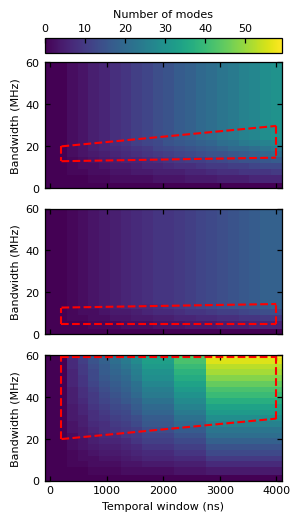

In [17]:
T_grid, F_grid = np.meshgrid(T_vals, F_vals)

encoding_keys = list(maps_3d_loaded_10.keys())
encoding_keys = [encoding_keys[1], encoding_keys[2], encoding_keys[0]]
# 各マップの周囲に0行・0列を追加
maps_padded = {}
for key in encoding_keys:
    M = maps_3d_loaded_10[key]
    # 下端に0行、左端に0列を追加
    M_padded = np.pad(M, ((1, 0), (1, 0)), mode='constant', constant_values=0)
    maps_padded[key] = M_padded

# 軸に対応する値も同様に拡張
T_vals_padded = np.insert(T_vals, 0, 0)
F_vals_padded = np.insert(F_vals, 0, 0)
T_grid, F_grid = np.meshgrid(T_vals_padded, F_vals_padded)

maps_stack = np.stack([maps_padded[key] for key in encoding_keys], axis=0)
max_values = maps_stack.max(axis=0) 
max_counts = (maps_stack == max_values).sum(axis=0)

vmin = maps_stack.min()
vmax = maps_stack.max()

fig, axes = plt.subplots(3, 1, figsize=(3.2, 5.3), sharex=True)

for ax, key, color in zip(axes, encoding_keys, colors):
    im = ax.pcolormesh(
        T_grid, F_grid*1e3, maps_padded[key],
        shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
    )

    if key=="Frequency-bin":
        ax.set_ylabel("Bandwidth (MHz)")
        ax.set_xlabel("Temporal window (ns)")
        ax.plot([T_vals.min(), T_vals.min()], [F_line_1.min()*1e3, F_vals.max()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.min(), T_vals.max()], [F_vals.max()*1e3-1, F_vals.max()*1e3-1], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_line_1.max()*1e3, F_vals.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_1, F_line_1*1e3, 'r--', lw=1.5)
        ax.set_ylim(0, 60)
    elif key=="Temporal-mode":
        ax.set_ylabel("Bandwidth (MHz)")
        ax.plot([T_vals.min(), T_vals.min()], [F_line_1.min()*1e3, F_line_2.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_line_1.max()*1e3, F_line_2.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_1, F_line_1*1e3, 'r--', lw=1.5)
        ax.plot(T_line_2, F_line_2*1e3, 'r--', lw=1.5)
        ax.set_ylim(0, 60)
    elif key=="Time-bin":
        ax.set_ylabel("Bandwidth (MHz)")
        ax.plot([T_vals.min(), T_vals.min()], [F_vals.min()*1e3, F_line_2.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.min(), T_vals.max()], [F_vals.min()*1e3, F_vals.min()*1e3], 'r--', lw=1.5)
        ax.plot([T_vals.max(), T_vals.max()], [F_vals.min()*1e3, F_line_2.max()*1e3], 'r--', lw=1.5)
        ax.plot(T_line_2, F_line_2*1e3, 'r--', lw=1.5)
        ax.set_ylim(0, 60)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location='top',
    fraction=0.04, pad=0.02, aspect=15, orientation='horizontal'
)
cbar.set_label("Number of modes")
# plt.savefig('Fig4_c1.pdf', bbox_inches='tight')
plt.show()


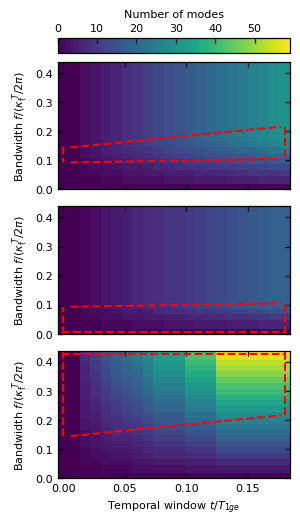

In [86]:
t_norm = 22.2*1e3
f_norm = 137.0*1e-3

T_grid, F_grid = np.meshgrid(T_vals, F_vals)

encoding_keys = list(maps_3d_loaded_10.keys())
encoding_keys = [encoding_keys[1], encoding_keys[2], encoding_keys[0]]

# --- 各マップに0行・0列を追加 ---
maps_padded = {}
for key in encoding_keys:
    M = maps_3d_loaded_10[key]
    M_padded = np.pad(M, ((1, 0), (1, 0)), mode='constant', constant_values=0)
    maps_padded[key] = M_padded

# --- 規格化する前に軸に合わせて0を追加 ---
T_vals_padded = np.insert(T_vals, 0, 0)
F_vals_padded = np.insert(F_vals, 0, 0)

# --- ★ 規格化 ---
T_vals_norm = T_vals_padded / t_norm
F_vals_norm = F_vals_padded / f_norm

# --- メッシュも規格化後で作る ---
T_grid_norm, F_grid_norm = np.meshgrid(T_vals_norm, F_vals_norm)

maps_stack = np.stack([maps_padded[key] for key in encoding_keys], axis=0)
max_values = maps_stack.max(axis=0) 
max_counts = (maps_stack == max_values).sum(axis=0)

vmin = maps_stack.min()
vmax = maps_stack.max()

fig, axes = plt.subplots(3, 1, figsize=(3.2, 5.3), sharex=True)

for ax, key, color in zip(axes, encoding_keys, colors):
#     ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#     ax.yaxis.get_offset_text().set_x(-0.08) 

    # --- 規格化後の pcolormesh ---
    im = ax.pcolormesh(
        T_grid_norm, F_grid_norm,
        maps_padded[key],
        shading="auto",
        cmap="viridis",
        vmin=vmin, vmax=vmax
    )

    ax.set_ylabel(r"Bandwidth $f/(\kappa_\mathrm{f}^{\,T}/2\pi)$")
    
    # --- 赤線も規格化してプロット ---
    if key == "Frequency-bin":
        ax.plot([T_vals_norm.min(), T_vals_norm.min()],
                [F_line_1.min()/f_norm, F_vals_norm.max()], 'r--', lw=1.5)
        ax.plot([T_vals_norm.min()-0.001, T_vals_norm.max()],
                [F_vals_norm.max()-.1e-1, F_vals_norm.max()-.1e-1], 'r--', lw=1.5)
        ax.plot([T_vals_norm.max(), T_vals_norm.max()],
                [F_line_1.max()/f_norm, F_vals_norm.max()], 'r--', lw=1.5)
        ax.plot(T_line_1/t_norm-0.003, F_line_1/f_norm, 'r--', lw=1.5)
        ax.set_ylim(0, F_vals_norm.max())

    elif key == "Temporal-mode":
        ax.plot([T_vals_norm.min(), T_vals_norm.min()],
                [F_line_1.min()/f_norm, F_line_2.min()/f_norm], 'r--', lw=1.5)
        ax.plot([T_vals_norm.max(), T_vals_norm.max()],
                [F_line_1.max()/f_norm, F_line_2.max()/f_norm], 'r--', lw=1.5)
        ax.plot(T_line_1/t_norm-0.003, F_line_1/f_norm, 'r--', lw=1.5)
        ax.plot(T_line_2/t_norm-0.003, F_line_2/f_norm, 'r--', lw=1.5)
        ax.set_ylim(0, F_vals_norm.max())

    elif key == "Time-bin":
        ax.plot([T_vals_norm.min(), T_vals_norm.min()],
                [F_vals_norm.min(), F_line_2.min()/f_norm], 'r--', lw=1.5)
        ax.plot([T_vals_norm.min()-0.001, T_vals_norm.max()],
                [F_vals_norm.min()+0.05e-1, F_vals_norm.min()+0.05e-1], 'r--', lw=1.5)
        ax.plot([T_vals_norm.max(), T_vals_norm.max()],
                [F_vals_norm.min(), F_line_2.max()/f_norm], 'r--', lw=1.5)
        ax.plot(T_line_2/t_norm-0.003, F_line_2/f_norm, 'r--', lw=1.5)
        ax.set_ylim(0, F_vals_norm.max())

    if key == "Frequency-bin":
        ax.set_xlabel(r"Temporal window $t/T_{1ge}$")

plt.tight_layout(rect=[0, 0, 0.95, 0.95])

# --- カラーバー ---
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)

cbar = fig.colorbar(
    sm, ax=fig.axes, 
    location="top",
    fraction=0.04, pad=0.02, aspect=15, orientation="horizontal"
)
cbar.set_label("Number of modes")
plt.savefig('Fig4_c1.pdf', bbox_inches='tight')
plt.show()


mode density

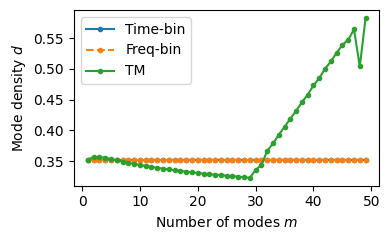

In [498]:
m_vals = np.arange(1, 50)

# 固定幅（time-bin と freq-bin）
delta_t0 = params["Time-bin"]["delta_t"]
delta_f0 = params["Time-bin"]["delta_f"]

# constant mode density
d_time = np.full_like(m_vals, 1 / (delta_t0 * delta_f0), dtype=float)
d_freq = np.full_like(m_vals, 1 / (delta_t0 * delta_f0), dtype=float)

# temporal-mode: モード個別のΔt, Δfを使用
d_temp = np.array([
    (m + 1) / (temporal_mode_params[m]["delta_t"] * temporal_mode_params[m]["delta_f"])
    for m in range(49)
])

plt.figure(figsize=(4, 2.5))
plt.plot(m_vals, d_time, 'o-', markersize=3, label='Time-bin')
plt.plot(m_vals, d_freq, 'o--', markersize=3, label='Freq-bin')
plt.plot(m_vals, d_temp, 'o-', markersize=3, label='TM')
plt.xlabel(r"Number of modes $m$")
plt.ylabel(r"Mode density $d$")
plt.legend()
plt.tight_layout()
plt.show()


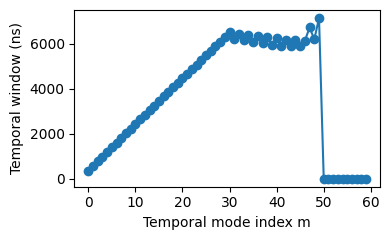

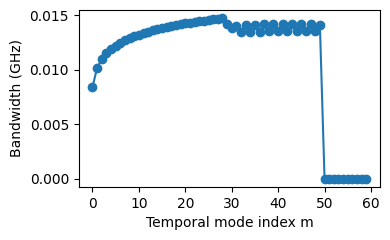

In [508]:
m_vals = np.array(list(temporal_mode_params.keys()))

delta_t_list = [temporal_mode_params[m]["delta_t"] for m in m_vals]
delta_f_list = [temporal_mode_params[m]["delta_f"] for m in m_vals]

plt.figure(figsize=(4, 2.5))
plt.plot(m_vals, delta_t_list, 'o-', label=r'$\Delta t$ (ns)')
# plt.plot(m_vals, delta_f_list, 's-', label=r'$\Delta f$ (MHz)')
plt.xlabel("Temporal mode index m")
plt.ylabel("Temporal window (ns)")
# plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 2.5))
# plt.plot(m_vals, delta_t_list, 'o-', label=r'$\Delta t$ (ns)')
plt.plot(m_vals, delta_f_list, 'o-', label=r'$\Delta f$ (MHz)')
plt.xlabel("Temporal mode index m")
plt.ylabel("Bandwidth (GHz)")
# plt.legend()
plt.tight_layout()
plt.show()
